# 🌳 Decision Trees (with Pruning) — Heart Disease Prediction

---

## 🎯 What Will You Learn?

- Understand how Decision Trees work using a medical example
- Learn about **Gini Impurity** and **Entropy** (the "question quality" measure)
- Understand **Overfitting** and why it's a problem
- Apply **Pre-Pruning** and **Post-Pruning** to fix overfitting
- Visualize the tree and understand every decision

---

## 📖 Table of Contents
1. What is a Decision Tree?
2. Loading and Exploring the Data
3. Data Preprocessing
4. Building an Unpruned Tree (and seeing overfitting)
5. Visualizing the Tree
6. Pre-Pruning Techniques
7. Post-Pruning (Cost-Complexity Pruning)
8. Comparing All Trees
9. Key Takeaways


---
## 1. 🏥 What is a Decision Tree?

### The "20 Questions" Game 🎮

Remember the "20 Questions" game? You think of something and others ask Yes/No questions:
- "Is it a living thing?" → Yes
- "Is it an animal?" → Yes  
- "Does it have 4 legs?" → No
- "Can it fly?" → Yes → "Is it a bird?" → Yes! **BIRD!**

**A Decision Tree works exactly like this!**

For heart disease prediction, a doctor might ask:
- "Age > 55?" → Yes
- "Has chest pain?" → Yes
- "Max heart rate > 150?" → No
- → **Prediction: Heart Disease Likely**

### Structure of a Decision Tree
```
            [Root Node]
           Age > 55?
          /          \
        Yes            No
       /                \
  [Chest Pain?]    [No Disease]
   /        \
  Yes        No
  /            \
[Disease]  [Test More]
```

**Key Terms:**
- **Root Node:** The first (top) question — most informative feature
- **Internal Nodes:** Questions in the middle
- **Leaf Nodes:** Final answers (Disease / No Disease)
- **Depth:** How many levels of questions the tree has

### How Does It Choose Which Question to Ask First?

The algorithm measures **impurity** — how mixed up are the answers?
- **Gini Impurity:** Measures how often you'd mislabel something randomly
- **Entropy:** Measures disorder (from information theory)

**The best question is the one that reduces impurity the most!**


In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                              classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Libraries imported!")

✅ Libraries imported!


---
## 2. 🏥 Loading and Exploring the Heart Disease Data

In [2]:
# Load the Heart Disease dataset
df = pd.read_csv('data/heart.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (918, 12)
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Understanding the Heart Disease Columns

| Column | Description | Values |
|--------|-------------|--------|
| `Age` | Patient's age in years | Numeric |
| `Sex` | Biological sex | M=Male, F=Female |
| `ChestPainType` | Type of chest pain | ATA, NAP, ASY, TA |
| `RestingBP` | Resting blood pressure (mm Hg) | Numeric |
| `Cholesterol` | Serum cholesterol (mg/dl) | Numeric |
| `FastingBS` | Fasting blood sugar > 120 mg/dl | 1=Yes, 0=No |
| `RestingECG` | Resting ECG results | Normal, ST, LVH |
| `MaxHR` | Maximum heart rate achieved | Numeric |
| `ExerciseAngina` | Exercise-induced angina | Y=Yes, N=No |
| `Oldpeak` | ST depression during exercise | Numeric |
| `ST_Slope` | Slope of peak ST segment | Up, Flat, Down |
| `HeartDisease` | **Target: 1=Disease, 0=Normal** | Binary |

In [3]:
# Basic statistics
print("Basic Statistics for Numeric Columns:")
df.describe().round(2)

Basic Statistics for Numeric Columns:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [4]:
# Target distribution
hd_counts = df['HeartDisease'].value_counts()
print(f"Heart Disease Distribution:")
print(f"  No Disease (0): {hd_counts[0]} ({hd_counts[0]/len(df)*100:.1f}%)")
print(f"  Has Disease (1): {hd_counts[1]} ({hd_counts[1]/len(df)*100:.1f}%)")
print(f"\nMissing values: {df.isnull().sum().sum()}")

Heart Disease Distribution:
  No Disease (0): 410 (44.7%)
  Has Disease (1): 508 (55.3%)

Missing values: 0


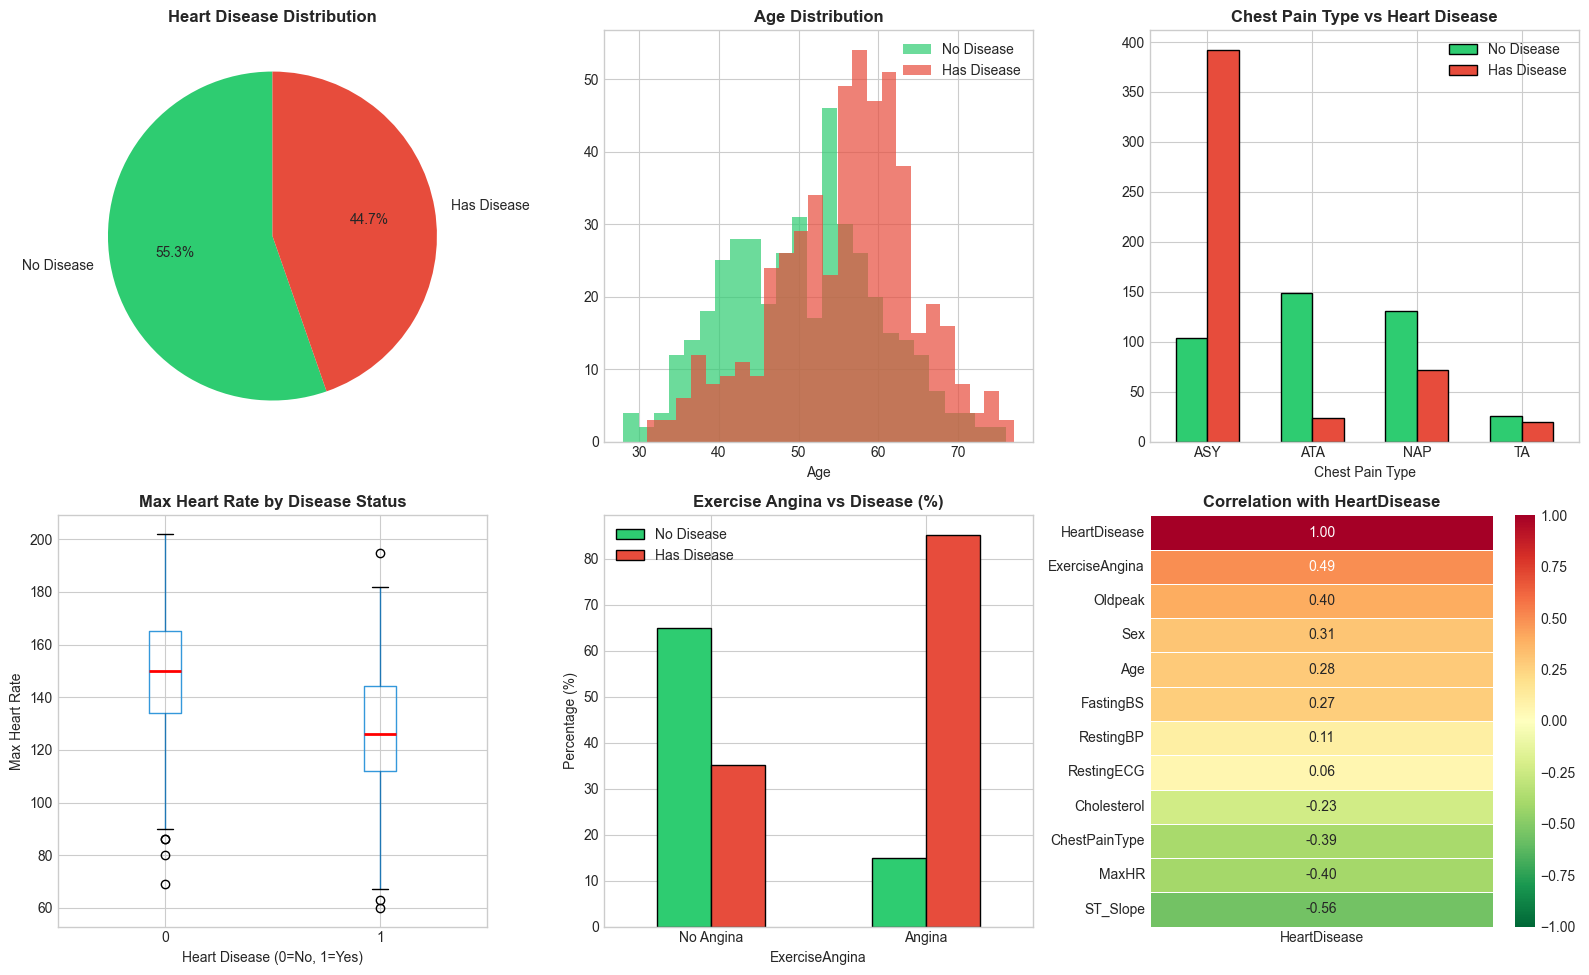

In [5]:
# Exploratory visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Heart Disease distribution
hd_counts.plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%', 
               labels=['No Disease', 'Has Disease'],
               colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0,0].set_title('Heart Disease Distribution', fontweight='bold')
axes[0,0].set_ylabel('')

# 2. Age distribution by disease
df[df['HeartDisease']==0]['Age'].hist(ax=axes[0,1], bins=25, alpha=0.7, 
                                       color='#2ecc71', label='No Disease')
df[df['HeartDisease']==1]['Age'].hist(ax=axes[0,1], bins=25, alpha=0.7, 
                                       color='#e74c3c', label='Has Disease')
axes[0,1].set_title('Age Distribution', fontweight='bold')
axes[0,1].legend()
axes[0,1].set_xlabel('Age')

# 3. Chest pain type vs Heart Disease
chest_hd = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
chest_hd.plot(kind='bar', ax=axes[0,2], color=['#2ecc71', '#e74c3c'], 
              edgecolor='black', width=0.6)
axes[0,2].set_title('Chest Pain Type vs Heart Disease', fontweight='bold')
axes[0,2].set_xlabel('Chest Pain Type')
axes[0,2].set_xticklabels(axes[0,2].get_xticklabels(), rotation=0)
axes[0,2].legend(['No Disease', 'Has Disease'])

# 4. Max HR boxplot
df.boxplot(column='MaxHR', by='HeartDisease', ax=axes[1,0],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='red', linewidth=2))
axes[1,0].set_title('Max Heart Rate by Disease Status', fontweight='bold')
axes[1,0].set_xlabel('Heart Disease (0=No, 1=Yes)')
axes[1,0].set_ylabel('Max Heart Rate')
plt.suptitle('')

# 5. Exercise Angina vs Disease
angina_hd = pd.crosstab(df['ExerciseAngina'], df['HeartDisease'])
angina_hd_pct = angina_hd.div(angina_hd.sum(axis=1), axis=0) * 100
angina_hd_pct.plot(kind='bar', ax=axes[1,1], color=['#2ecc71', '#e74c3c'],
                   edgecolor='black', width=0.5)
axes[1,1].set_title('Exercise Angina vs Disease (%)', fontweight='bold')
axes[1,1].set_xticklabels(['No Angina', 'Angina'], rotation=0)
axes[1,1].legend(['No Disease', 'Has Disease'])
axes[1,1].set_ylabel('Percentage (%)')

# 6. Correlation heatmap
df_numeric = df.copy()
for col in ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']:
    df_numeric[col] = LabelEncoder().fit_transform(df_numeric[col])
corr = df_numeric.corr()
sns.heatmap(corr[['HeartDisease']].sort_values('HeartDisease', ascending=False),
            ax=axes[1,2], annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=-1, vmax=1, linewidths=0.5)
axes[1,2].set_title('Correlation with HeartDisease', fontweight='bold')

plt.tight_layout()
plt.savefig('heart_eda.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 3. 🔧 Data Preprocessing

In [ ]:
# Encode categorical columns
df_model = df.copy()
le = LabelEncoder()

cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print("le->class", le.classes_)
    print("#####", le.transform(le.classes_))
    print(f"  '{col}' encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Features and target
X = df_model.drop('HeartDisease', axis=1)
y = df_model['HeartDisease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Preprocessing done!")
print(f"   Training: {len(X_train)} samples | Testing: {len(X_test)} samples")
print(f"   Note: Decision Trees do NOT require feature scaling!")

vineet ['F' 'M']
##### [0 1]
  'Sex' encoded: {'F': np.int64(0), 'M': np.int64(1)}
vineet ['ASY' 'ATA' 'NAP' 'TA']
##### [0 1 2 3]
  'ChestPainType' encoded: {'ASY': np.int64(0), 'ATA': np.int64(1), 'NAP': np.int64(2), 'TA': np.int64(3)}
vineet ['LVH' 'Normal' 'ST']
##### [0 1 2]
  'RestingECG' encoded: {'LVH': np.int64(0), 'Normal': np.int64(1), 'ST': np.int64(2)}
vineet ['N' 'Y']
##### [0 1]
  'ExerciseAngina' encoded: {'N': np.int64(0), 'Y': np.int64(1)}
vineet ['Down' 'Flat' 'Up']
##### [0 1 2]
  'ST_Slope' encoded: {'Down': np.int64(0), 'Flat': np.int64(1), 'Up': np.int64(2)}

✅ Preprocessing done!
   Training: 734 samples | Testing: 184 samples
   Note: Decision Trees do NOT require feature scaling!


In [22]:
name = ['Alice', 'Bob', 'Charlie', 'David']
age = [23, 30, 35, 40]
education = ['High School', 'Bachelor', 'Master', 'PhD']
print(list(zip(name, age, education)))

[('Alice', 23, 'High School'), ('Bob', 30, 'Bachelor'), ('Charlie', 35, 'Master'), ('David', 40, 'PhD')]


### ✅ No Scaling Needed for Decision Trees!

Unlike KNN and Logistic Regression, **Decision Trees split by thresholds** (e.g., Age > 55?). They don't use distances or formulas with numbers. So scaling doesn't affect the result!

---
## 4. 🌳 Building an Unpruned Decision Tree

In [7]:
# Build a fully grown (unpruned) decision tree
# NO restrictions = tree grows until every leaf is pure
tree_full = DecisionTreeClassifier(random_state=42)  # No max_depth!

tree_full.fit(X_train, y_train)

# Predictions
train_acc_full = accuracy_score(y_train, tree_full.predict(X_train))
test_acc_full = accuracy_score(y_test, tree_full.predict(X_test))

print("Unpruned (Full) Decision Tree:")
print(f"  Tree Depth:        {tree_full.get_depth()} levels")
print(f"  Number of Leaves:  {tree_full.get_n_leaves()}")
print(f"  Training Accuracy: {train_acc_full*100:.2f}% ← Perfect! (suspicious!)")
print(f"  Test Accuracy:     {test_acc_full*100:.2f}% ← What really matters")
print()
print("⚠️  Notice: Training = 100% but Test is lower → OVERFITTING!")

Unpruned (Full) Decision Tree:
  Tree Depth:        14 levels
  Number of Leaves:  106
  Training Accuracy: 100.00% ← Perfect! (suspicious!)
  Test Accuracy:     78.80% ← What really matters

⚠️  Notice: Training = 100% but Test is lower → OVERFITTING!


### ❗ What is Overfitting?

Imagine a student who **memorized every answer** in the textbook word-by-word.
- On the exact same questions → **100% correct!**
- On slightly different exam questions → **FAILS!**

The student didn't learn the *concept*, they memorized the *examples*.

**Overfitting in Decision Trees:**
An unpruned tree grows until it has a separate rule for almost every single training example. It "memorizes" the training data but can't generalize to new data.

**The solution is PRUNING** — cutting branches that are too specific.

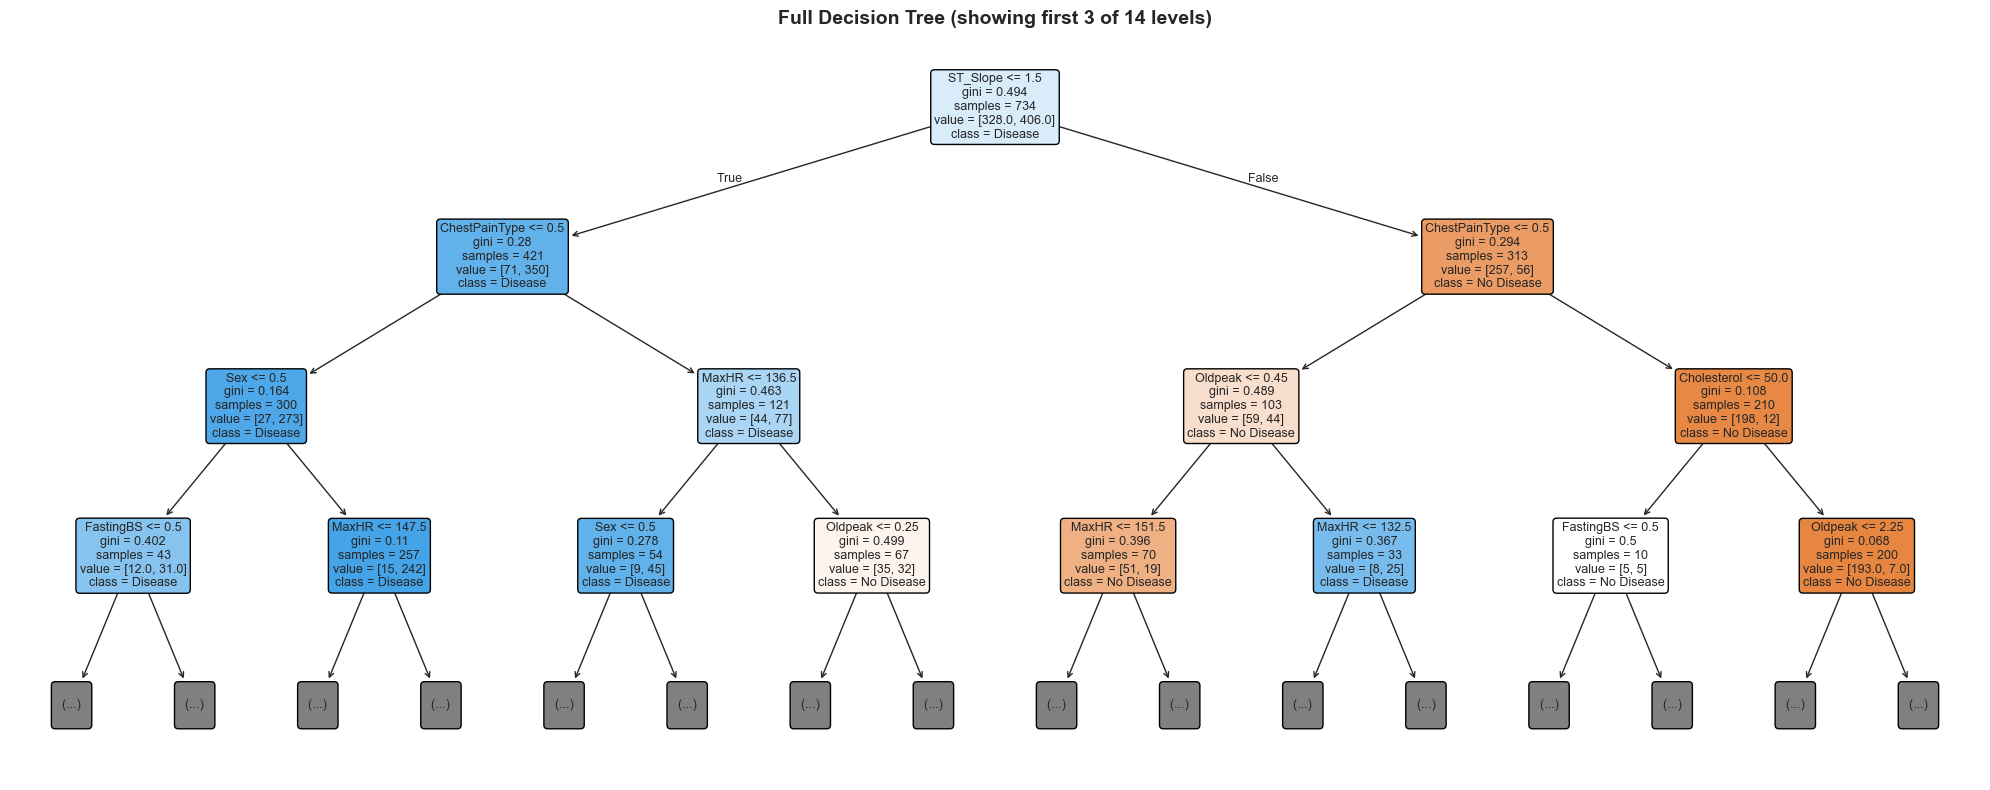

Full tree has 14 levels — much too complex!


In [8]:
# Visualize a SMALL portion of the full tree to show its complexity
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(tree_full, feature_names=X.columns, class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, max_depth=3,  # Only show first 3 levels
          ax=ax, fontsize=9,
          impurity=True, proportion=False)
ax.set_title(f'Full Decision Tree (showing first 3 of {tree_full.get_depth()} levels)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('full_tree.png', dpi=80, bbox_inches='tight')
plt.show()
print(f"Full tree has {tree_full.get_depth()} levels — much too complex!")

---
## 5. ✂️ Pre-Pruning Techniques

Pre-pruning = **stopping the tree from growing too large** in the first place.

### Technique 1: `max_depth` — Limit tree height
### Technique 2: `min_samples_split` — Require minimum samples to split
### Technique 3: `min_samples_leaf` — Require minimum samples in each leaf

In [9]:
# Technique 1: max_depth — try different depths
print("Effect of max_depth:")
print(f"{'Depth':<8} {'Train Acc':<12} {'Test Acc':<12} {'Leaves':<10} {'Verdict'}")
print("-" * 60)
for depth in [2, 3, 4, 5, 6, 8, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, tree.predict(X_train))
    te_acc = accuracy_score(y_test, tree.predict(X_test))
    leaves = tree.get_n_leaves()
    depth_label = str(depth) if depth else 'None (full)'
    if te_acc > 0.85:
        verdict = "✅ Good"
    elif te_acc > 0.80:
        verdict = "🟡 OK"
    else:
        verdict = "❌ Poor"
    print(f"{depth_label:<8} {tr_acc*100:.1f}%      {te_acc*100:.1f}%      {leaves:<10} {verdict}")

Effect of max_depth:
Depth    Train Acc    Test Acc     Leaves     Verdict
------------------------------------------------------------
2        82.7%      76.1%      4          ❌ Poor
3        85.4%      82.1%      8          🟡 OK
4        87.1%      81.0%      16         🟡 OK
5        89.5%      81.0%      28         🟡 OK
6        91.7%      82.6%      44         🟡 OK
8        97.1%      77.7%      78         ❌ Poor
None (full) 100.0%      78.8%      106        ❌ Poor


In [10]:
# Technique 2: min_samples_split — minimum samples required to make a split
print("Effect of min_samples_split (with max_depth=5):")
print(f"{'min_split':<12} {'Train Acc':<12} {'Test Acc':<12} {'Leaves'}")
print("-" * 50)
for min_split in [2, 5, 10, 20, 50]:
    tree = DecisionTreeClassifier(max_depth=5, min_samples_split=min_split, random_state=42)
    tree.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, tree.predict(X_train))
    te_acc = accuracy_score(y_test, tree.predict(X_test))
    print(f"{min_split:<12} {tr_acc*100:.1f}%      {te_acc*100:.1f}%      {tree.get_n_leaves()}")

Effect of min_samples_split (with max_depth=5):
min_split    Train Acc    Test Acc     Leaves
--------------------------------------------------
2            89.5%      81.0%      28
5            89.5%      81.0%      28
10           89.1%      82.1%      26
20           88.4%      79.9%      24
50           87.2%      80.4%      16


In [11]:
# Build the best pre-pruned tree based on what we observed
best_prepruned = DecisionTreeClassifier(
    max_depth=5,          # Don't grow deeper than 5 levels
    min_samples_split=10, # Need at least 10 samples to make a split
    min_samples_leaf=5,   # Each leaf must have at least 5 samples
    random_state=42
)
best_prepruned.fit(X_train, y_train)

train_acc_pre = accuracy_score(y_train, best_prepruned.predict(X_train))
test_acc_pre = accuracy_score(y_test, best_prepruned.predict(X_test))

print("Pre-Pruned Decision Tree (max_depth=5, min_samples_split=10, min_samples_leaf=5):")
print(f"  Tree Depth:        {best_prepruned.get_depth()} levels")
print(f"  Number of Leaves:  {best_prepruned.get_n_leaves()}")
print(f"  Training Accuracy: {train_acc_pre*100:.2f}%")
print(f"  Test Accuracy:     {test_acc_pre*100:.2f}%")

Pre-Pruned Decision Tree (max_depth=5, min_samples_split=10, min_samples_leaf=5):
  Tree Depth:        5 levels
  Number of Leaves:  27
  Training Accuracy: 88.56%
  Test Accuracy:     78.80%


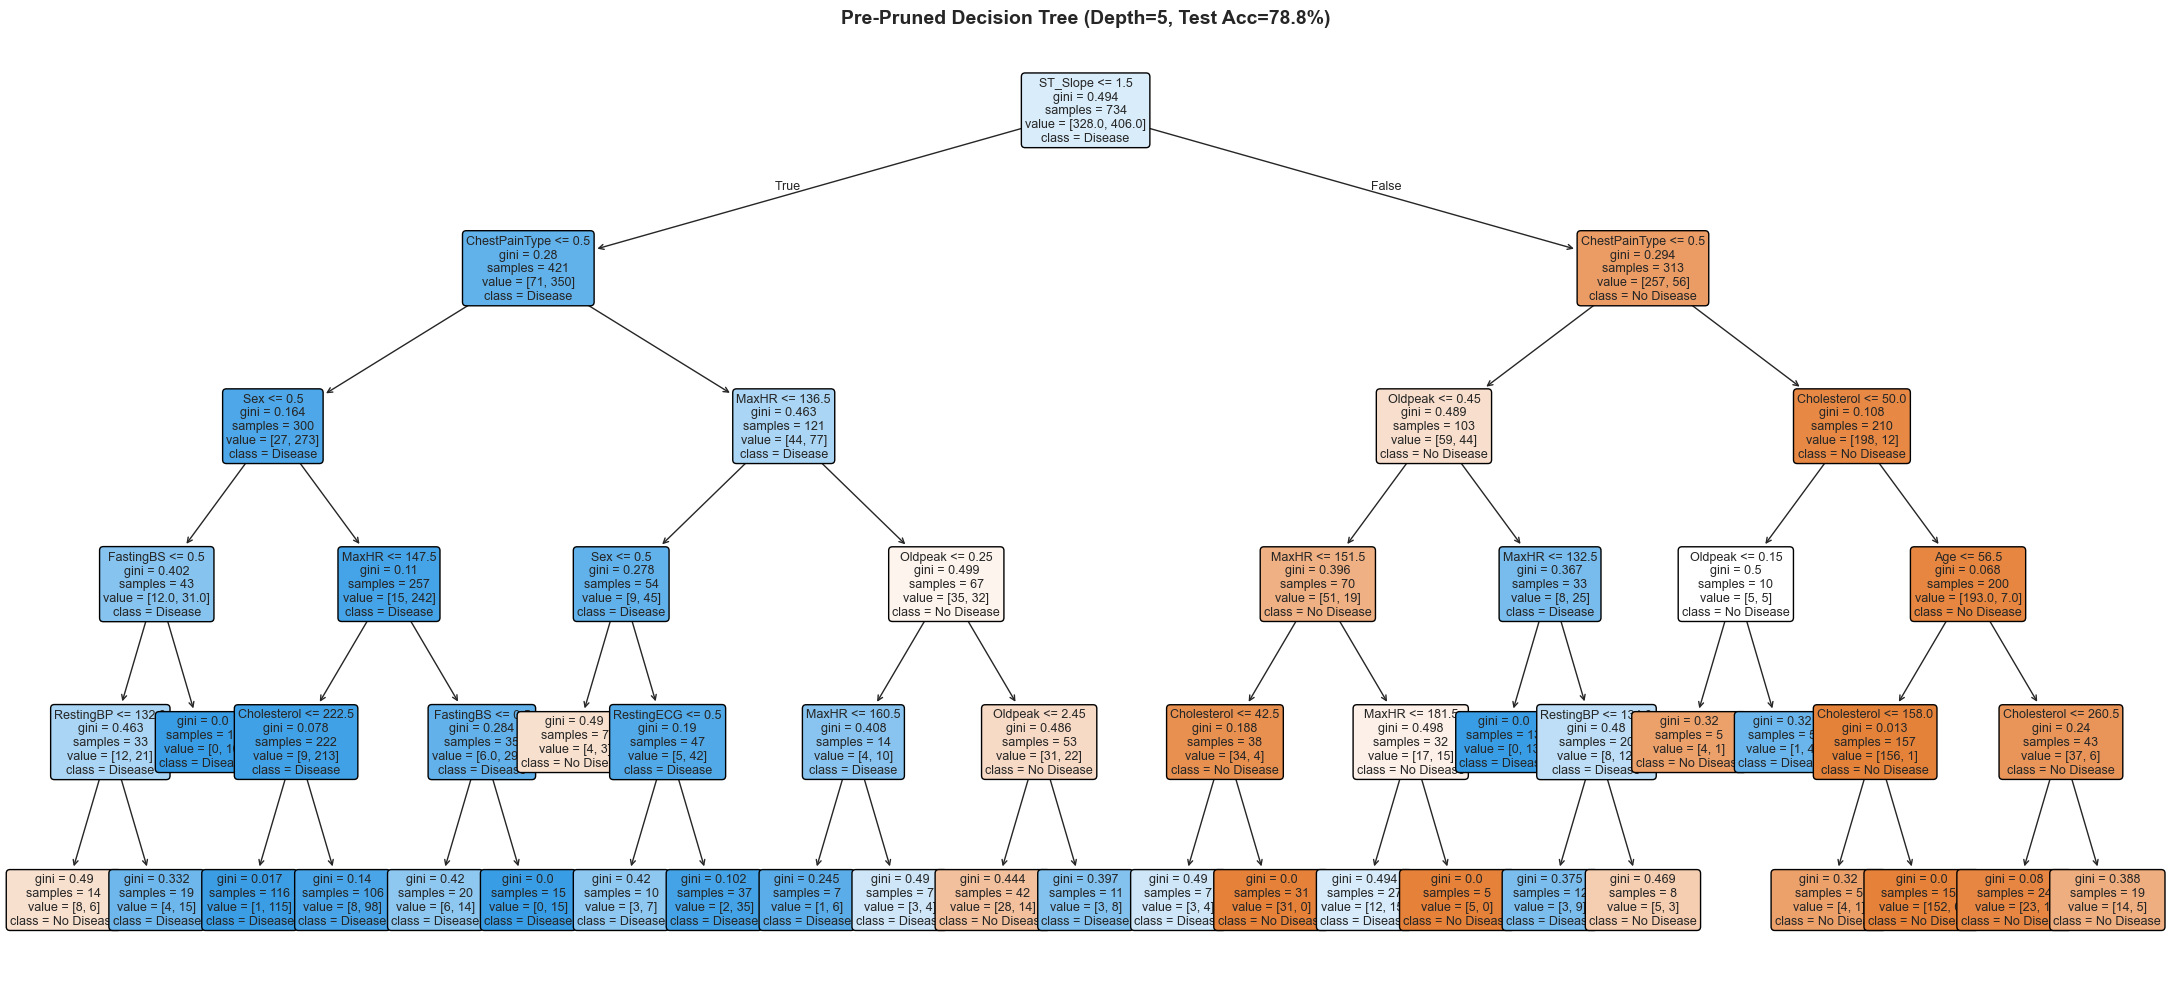

In [12]:
# Visualize the Pre-Pruned Tree
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(best_prepruned, feature_names=X.columns, 
          class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, ax=ax, fontsize=9,
          impurity=True, proportion=False)
ax.set_title(f'Pre-Pruned Decision Tree (Depth={best_prepruned.get_depth()}, Test Acc={test_acc_pre*100:.1f}%)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('prepruned_tree.png', dpi=80, bbox_inches='tight')
plt.show()

In [13]:
# Print the tree as text rules — very readable!
print("Decision Tree as Text Rules:")
print("=" * 60)
rules = export_text(best_prepruned, feature_names=list(X.columns))
print(rules[:2000])  # Print first 2000 characters
print("...(tree continues)...")

Decision Tree as Text Rules:
|--- ST_Slope <= 1.50
|   |--- ChestPainType <= 0.50
|   |   |--- Sex <= 0.50
|   |   |   |--- FastingBS <= 0.50
|   |   |   |   |--- RestingBP <= 132.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- RestingBP >  132.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- FastingBS >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Sex >  0.50
|   |   |   |--- MaxHR <= 147.50
|   |   |   |   |--- Cholesterol <= 222.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Cholesterol >  222.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- MaxHR >  147.50
|   |   |   |   |--- FastingBS <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- FastingBS >  0.50
|   |   |   |   |   |--- class: 1
|   |--- ChestPainType >  0.50
|   |   |--- MaxHR <= 136.50
|   |   |   |--- Sex <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Sex >  0.50
|   |   |   |   |--- RestingECG <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- RestingEC

---
## 6. ✂️ Post-Pruning: Cost-Complexity Pruning (ccp_alpha)

Post-pruning = **let the tree grow fully, then cut back branches that don't improve generalization**.

This uses a parameter called **`ccp_alpha`** (cost-complexity pruning alpha):
- **Small alpha (close to 0):** Keep almost all branches (complex tree)
- **Large alpha:** Cut many branches (simpler tree)

We find the best alpha by testing different values — similar to finding the best K in KNN!

In [14]:
# Find the optimal ccp_alpha value
# sklearn can automatically compute effective alphas
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"Number of alpha values to test: {len(ccp_alphas)}")
print(f"Alpha range: {ccp_alphas.min():.6f} to {ccp_alphas.max():.4f}")

Number of alpha values to test: 57
Alpha range: 0.000000 to 0.2082


In [15]:
# Train a tree for each alpha value
train_accs = []
test_accs = []
tree_depths = []
n_leaves = []

# Only test up to a reasonable range
alphas_to_test = ccp_alphas[ccp_alphas <= 0.05]

for alpha in alphas_to_test:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs.append(accuracy_score(y_test, tree.predict(X_test)))
    tree_depths.append(tree.get_depth())
    n_leaves.append(tree.get_n_leaves())

print(f"Tested {len(alphas_to_test)} alpha values")
best_alpha_idx = np.argmax(test_accs)
best_alpha = alphas_to_test[best_alpha_idx]
best_test_acc = test_accs[best_alpha_idx]
print(f"Best alpha: {best_alpha:.6f} with Test Accuracy: {best_test_acc*100:.2f}%")

Tested 56 alpha values
Best alpha: 0.002113 with Test Accuracy: 83.15%


ValueError: 'p-^' is not a valid format string (two marker symbols)

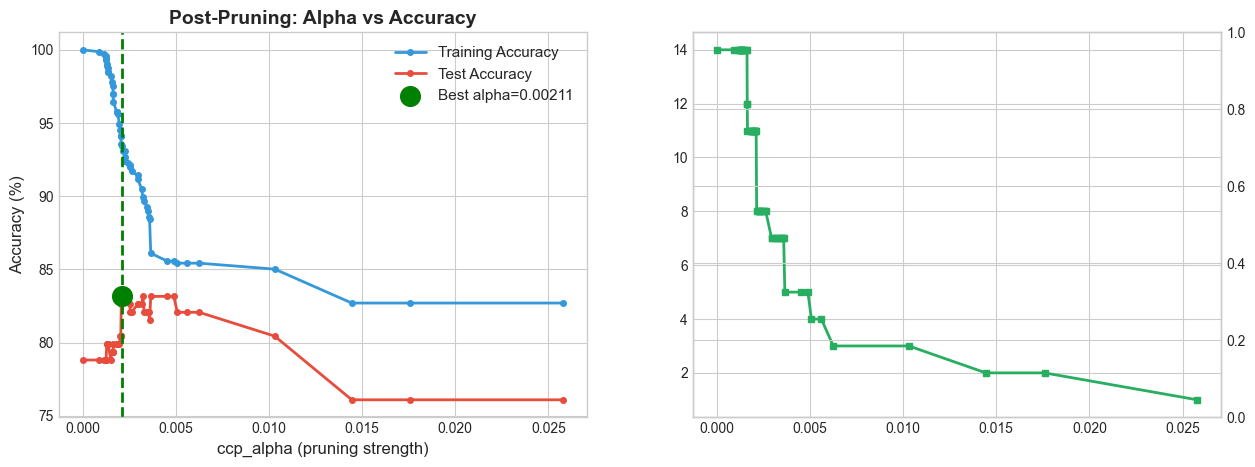

In [16]:
# Plot alpha vs accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy vs alpha
axes[0].plot(alphas_to_test, [a*100 for a in train_accs], 'b-o', markersize=4,
             linewidth=2, label='Training Accuracy', color='#3498db')
axes[0].plot(alphas_to_test, [a*100 for a in test_accs], 'r-o', markersize=4,
             linewidth=2, label='Test Accuracy', color='#e74c3c')
axes[0].axvline(x=best_alpha, color='green', linestyle='--', linewidth=2)
axes[0].scatter([best_alpha], [best_test_acc*100], color='green', s=200, zorder=5,
                label=f'Best alpha={best_alpha:.5f}')
axes[0].set_xlabel('ccp_alpha (pruning strength)', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Post-Pruning: Alpha vs Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)

# Tree size vs alpha
axes[1].plot(alphas_to_test, tree_depths, 'g-s', markersize=4, linewidth=2,
             label='Tree Depth', color='#27ae60')
ax2 = axes[1].twinx()
ax2.plot(alphas_to_test, n_leaves, 'p-^', markersize=4, linewidth=2,
         label='Number of Leaves', color='#8e44ad')
axes[1].axvline(x=best_alpha, color='orange', linestyle='--', linewidth=2)
axes[1].set_xlabel('ccp_alpha', fontsize=12)
axes[1].set_ylabel('Tree Depth', fontsize=12, color='#27ae60')
ax2.set_ylabel('Number of Leaves', fontsize=12, color='#8e44ad')
axes[1].set_title('Tree Complexity vs Alpha', fontsize=14, fontweight='bold')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=10)

plt.tight_layout()
plt.savefig('postpruning_alpha.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Build the best post-pruned tree
best_postpruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_postpruned.fit(X_train, y_train)

train_acc_post = accuracy_score(y_train, best_postpruned.predict(X_train))
test_acc_post = accuracy_score(y_test, best_postpruned.predict(X_test))
auc_post = roc_auc_score(y_test, best_postpruned.predict_proba(X_test)[:, 1])

print(f"Post-Pruned Decision Tree (ccp_alpha={best_alpha:.6f}):")
print(f"  Tree Depth:        {best_postpruned.get_depth()} levels")
print(f"  Number of Leaves:  {best_postpruned.get_n_leaves()}")
print(f"  Training Accuracy: {train_acc_post*100:.2f}%")
print(f"  Test Accuracy:     {test_acc_post*100:.2f}%")
print(f"  ROC-AUC:           {auc_post:.4f}")

---
## 7. 📊 Comparing All Trees

In [ ]:
# Get metrics for all models
auc_full = roc_auc_score(y_test, tree_full.predict_proba(X_test)[:, 1])
auc_pre = roc_auc_score(y_test, best_prepruned.predict_proba(X_test)[:, 1])

results = pd.DataFrame({
    'Model': ['Unpruned Tree', 'Pre-Pruned Tree', 'Post-Pruned Tree'],
    'Depth': [tree_full.get_depth(), best_prepruned.get_depth(), best_postpruned.get_depth()],
    'Leaves': [tree_full.get_n_leaves(), best_prepruned.get_n_leaves(), best_postpruned.get_n_leaves()],
    'Train Acc (%)': [train_acc_full*100, train_acc_pre*100, train_acc_post*100],
    'Test Acc (%)': [test_acc_full*100, test_acc_pre*100, test_acc_post*100],
    'ROC-AUC': [auc_full, auc_pre, auc_post]
})

print("Comparison of All Decision Trees:")
print(results.round(2).to_string(index=False))

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ['Unpruned', 'Pre-Pruned', 'Post-Pruned']
train_accs_all = [train_acc_full*100, train_acc_pre*100, train_acc_post*100]
test_accs_all = [test_acc_full*100, test_acc_pre*100, test_acc_post*100]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

# Bar chart comparison
x = np.arange(len(models))
width = 0.35
bars1 = axes[0].bar(x - width/2, train_accs_all, width, label='Train', 
                    color='#3498db', edgecolor='black', alpha=0.85)
bars2 = axes[0].bar(x + width/2, test_accs_all, width, label='Test', 
                    color='#e74c3c', edgecolor='black', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Train vs Test Accuracy', fontweight='bold')
axes[0].legend()
axes[0].set_ylim([75, 105])
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

# ROC curves
for model, color, label in [
    (tree_full, '#e74c3c', 'Unpruned'),
    (best_prepruned, '#f39c12', 'Pre-Pruned'),
    (best_postpruned, '#2ecc71', 'Post-Pruned')
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, lw=2, color=color, label=f'{label} (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves Comparison', fontweight='bold')
axes[1].legend(fontsize=9)

# Tree complexity
leaves_all = [tree_full.get_n_leaves(), best_prepruned.get_n_leaves(), best_postpruned.get_n_leaves()]
bars = axes[2].bar(models, leaves_all, color=colors, edgecolor='black')
axes[2].set_ylabel('Number of Leaves (Complexity)')
axes[2].set_title('Tree Complexity Comparison', fontweight='bold')
for bar, val in zip(bars, leaves_all):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('tree_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Feature Importance
fi = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_postpruned.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(fi['Feature'], fi['Importance'], 
               color=plt.cm.YlOrRd(fi['Importance'] / fi['Importance'].max()),
               edgecolor='black')
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Feature Importance — Heart Disease\n(What the tree considers most important)', 
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, fi['Importance']):
    if val > 0:
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance_tree.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Final detailed evaluation
print("Post-Pruned Decision Tree — Final Evaluation:")
print("=" * 55)
y_pred_final = best_postpruned.predict(X_test)
print(classification_report(y_test, y_pred_final, target_names=['No Disease', 'Has Disease']))

cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Predicted: No Disease', 'Predicted: Disease'],
            yticklabels=['Actual: No Disease', 'Actual: Disease'],
            linewidths=2, linecolor='white', annot_kws={'size': 18, 'weight': 'bold'})
ax.set_title('Confusion Matrix — Post-Pruned Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tree_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 8. 🎓 Key Takeaways

### Decision Trees:
- Work by asking a series of Yes/No questions (just like a doctor!)
- Easy to understand and visualize
- Can handle both numbers and categories
- **Don't need feature scaling**

### Overfitting:
- An unpruned tree memorizes training data (100% train accuracy)
- But performs worse on new data → **overfitting**
- Signs: Large gap between train accuracy and test accuracy

### Pruning Strategies:

| Method | How | When to Use |
|--------|-----|-------------|
| **max_depth** | Limit tree levels | Quick control |
| **min_samples_split** | Min samples to split | Avoid tiny splits |
| **min_samples_leaf** | Min samples per leaf | Ensure stable leaves |
| **ccp_alpha** (post-prune) | Penalize complexity | Fine-tuned control |

### Practical Rule of Thumb:
- Start with `max_depth=4` or `5`
- Use cross-validation to fine-tune
- If tree is still overfitting → try `ccp_alpha`

### Next Steps:
**Random Forest** = many decision trees working together (like a committee of experts!).


In [ ]:
print("=" * 55)
print("        DECISION TREE SUMMARY")
print("=" * 55)
print(f"  Dataset:          Heart Disease")
print(f"  Total Patients:   {len(df)}")
print(f"  Unpruned Acc:     {test_acc_full*100:.2f}% (Overfit!)")
print(f"  Pre-Pruned Acc:   {test_acc_pre*100:.2f}%")
print(f"  Post-Pruned Acc:  {test_acc_post*100:.2f}%  ← Best")
print(f"  Post-Pruned AUC:  {auc_post:.4f}")
print("=" * 55)
print("Next: Random Forest — Multiple Trees = Better Results!")